# 🤖 TFT Training v3 — Multi-country Electricity Forecasting

**Mục tiêu:** Train mô hình **Temporal Fusion Transformer (TFT)** trên bộ dữ liệu đa quốc gia  
và lưu checkpoint để làm **pretrained model** cho bước Transfer Learning sang Việt Nam.

---
| Mục | Thông tin |
|---|---|
| Dataset | `tft_premodel_dataset_EDA.csv` (34,614 rows × 30 cols) |
| Entities | 20 quốc gia |
| Series target | Coal, Gas, Hydro, Solar, Wind, Bioenergy, Nuclear, Other Fossil, Other Renewables |
| Encoder length | 24 tháng |
| Prediction length | 6 tháng |
| Checkpoint output | `checkpoint/tft_v3_best.ckpt` |

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — IMPORTS & DEVICE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, os, json, copy, shutil
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateMonitor
)
from lightning.pytorch.loggers import TensorBoardLogger

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ PyTorch  : {torch.__version__}')
print(f'   Device   : {DEVICE}',
      f'({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else '')
print(f'   Lightning : {pl.__version__}')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR  = Path(r'C:\Users\ADMIN\Downloads\MODEL_TFT')
DATA_PATH = BASE_DIR / 'data' / 'processed' / 'training_data' / 'tft_premodel_dataset_EDA.csv'
CKPT_DIR  = BASE_DIR / 'checkpoint'
LOG_DIR   = BASE_DIR / 'lightning_logs' / 'tft_v3'
CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f'   Data      : {DATA_PATH}')
print(f'   Checkpoint: {CKPT_DIR}')

✅ PyTorch  : 2.4.1+cpu
   Device   : cpu 
   Lightning : 2.6.1
   Data      : C:\Users\ADMIN\Downloads\MODEL_TFT\data\processed\training_data\tft_premodel_dataset_EDA.csv
   Checkpoint: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — HYPERPARAMETERS & CONFIG
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CFG = dict(
    # ── Dataset ───────────────────────────────────────────────────────────────
    max_encoder_length    = 24,
    max_prediction_length = 6,
    min_series_length     = 30,   # encoder + prediction
    val_cutoff_months     = 12,   # dùng 12 tháng cuối làm validation

    # ── Model ─────────────────────────────────────────────────────────────────
    hidden_size           = 128,
    attention_head_size   = 4,
    dropout               = 0.15,
    hidden_continuous_size= 32,
    lstm_layers           = 2,

    # ── Training ──────────────────────────────────────────────────────────────
    learning_rate         = 3e-4,  # adamw cần LR nhỏ hơn ranger
    batch_size            = 64,
    max_epochs            = 80,
    gradient_clip_val     = 0.1,
    patience              = 12,    # EarlyStopping
    num_workers           = 0,     # Windows: giữ 0

    # ── Quantiles ─────────────────────────────────────────────────────────────
    loss_quantiles        = [0.1, 0.25, 0.5, 0.75, 0.9],

    # ── Seed ──────────────────────────────────────────────────────────────────
    seed                  = 42,
)

pl.seed_everything(CFG['seed'], workers=True)
print('📋 Cấu hình hiện tại:')
for k, v in CFG.items():
    print(f'   {k:<28}: {v}')

Seed set to 42


📋 Cấu hình hiện tại:
   max_encoder_length          : 24
   max_prediction_length       : 6
   min_series_length           : 30
   val_cutoff_months           : 12
   hidden_size                 : 128
   attention_head_size         : 4
   dropout                     : 0.15
   hidden_continuous_size      : 32
   lstm_layers                 : 2
   learning_rate               : 0.0003
   batch_size                  : 64
   max_epochs                  : 80
   gradient_clip_val           : 0.1
   patience                    : 12
   num_workers                 : 0
   loss_quantiles              : [0.1, 0.25, 0.5, 0.75, 0.9]
   seed                        : 42


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD & LỌC DỮ LIỆU (FIXED: NO LEAKAGE, NO NaNs)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df_raw = pd.read_csv(DATA_PATH)
df_raw['date'] = pd.to_datetime(df_raw['date'])
print(f'Raw shape: {df_raw.shape}')

# ── Chỉ giữ các series là nguồn điện thực sự ──────────────────────────────────
TARGET_SERIES = [
    'Coal', 'Gas', 'Hydro', 'Solar', 'Wind',
    'Bioenergy', 'Nuclear', 'Other Fossil', 'Other Renewables',
]
df = df_raw[df_raw['series'].isin(TARGET_SERIES)].copy()

# ── Shift weather features to remove leakage ─────────────────────────────
weather_cols = ['temperature', 'solar', 'humidity', 'precipitation']
for col in weather_cols:
    if col in df.columns:
        # Shift to use past data only
        df[col] = df.groupby(['entity', 'series'])[col].shift(1)
        # Fill NaNs created by shifting or missing in raw data
        df[col] = df.groupby(['entity', 'series'])[col].transform(lambda x: x.fillna(0))
print('✅ Weather features shifted & NaNs filled (Zero Leakage).')

# ── Fill NaN từ lag features ──────────────────────────────────────────────────
lag_cols = ['gen_lag_1','gen_lag_3','gen_lag_12',
            'roll_mean_3','roll_mean_6','roll_std_3','roll_max_6',
            'yoy_change','prec_lag_1','prec_lag_2']
for col in lag_cols:
    if col in df.columns:
        df[col] = df.groupby(['entity','series'])[col].transform(lambda x: x.fillna(0))

# ── Lọc series đủ độ dài ──────────────────────────────────────────────────────
counts  = df.groupby(['entity','series']).size()
valid   = counts[counts >= CFG['min_series_length']].reset_index()[['entity','series']]
df      = df.merge(valid, on=['entity','series'])

# ── Tạo time_idx liên tục per group ──────────────────────────────────────────
df = df.sort_values(['entity','series','date'])
df['time_idx'] = df.groupby(['entity','series'])['date'].rank(method='dense').astype(int) - 1

print(f'✅ Preprocessing done. Total Missing: {df.isnull().sum().sum()}')
print(f'   Shape: {df.shape} | Groups: {df.groupby(["entity","series"]).ngroups}')

Raw shape: (30290, 30)
✅ Weather features shifted & NaNs filled (Zero Leakage).
✅ Preprocessing done. Total Missing: 0
   Shape: (13859, 30) | Groups: 151


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — TRAIN / VALIDATION SPLIT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Dùng time_idx để cắt: toàn bộ data nhưng chỉ predict phần cuối
training_cutoff = int(df['time_idx'].max()) - CFG['val_cutoff_months']
val_cutoff_date = df['date'].max() - pd.DateOffset(months=CFG['val_cutoff_months'])

print(f'📅 Train/Val Split:')
print(f'   training_cutoff (time_idx) : {training_cutoff}')
print(f'   val_cutoff_date            : {val_cutoff_date.date()}')
print(f'   Train rows                 : {(df["time_idx"] <= training_cutoff).sum():,}')
print(f'   Val rows                   : {(df["time_idx"] >  training_cutoff).sum():,}')

📅 Train/Val Split:
   training_cutoff (time_idx) : 83
   val_cutoff_date            : 2024-12-01
   Train rows                 : 12,451
   Val rows                   : 1,408


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — TimeSeriesDataSet
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

STATIC_CATEGORICALS = ['entity']

TIME_VARYING_KNOWN_REALS = [
    'time_idx',
    'month', 'month_sin', 'month_cos', 'quarter', 'year',
]

TIME_VARYING_UNKNOWN_REALS = [
    'generation_TWh',       # target (autoregressive)
    'temperature',          # Shifted observation
    'solar',                # Shifted observation
    'humidity',             # Shifted observation
    'temperature',          # Shifted observation
    'solar',                # Shifted observation
    'humidity',             # Shifted observation
    'precipitation',
    'log_precipitation',
    'prec_zscore',
    'gen_lag_1',
    'gen_lag_3',
    'gen_lag_12',
    'roll_mean_3',
    'roll_mean_6',
    'roll_std_3',
    'roll_max_6',
    'yoy_change',
    'temp_anomaly',
    'solar_norm',
    'prec_lag_1',
    'prec_lag_2',
]

# ── Kiểm tra columns ──────────────────────────────────────────────────────────
all_needed = (STATIC_CATEGORICALS + TIME_VARYING_KNOWN_REALS +
              TIME_VARYING_UNKNOWN_REALS + ['series'])
missing_cols = [c for c in all_needed if c not in df.columns]
if missing_cols:
    print(f'⚠️  Thiếu columns: {missing_cols}')
else:
    print('✅ Tất cả columns đều có mặt')

# ── Tạo training dataset ──────────────────────────────────────────────────────
print('⏳ Đang tạo TimeSeriesDataSet...')
training = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx                         = 'time_idx',
    target                           = 'generation_TWh',
    group_ids                        = ['entity', 'series'],
    min_encoder_length               = CFG['max_encoder_length'] // 2,
    max_encoder_length               = CFG['max_encoder_length'],
    min_prediction_length            = 1,
    max_prediction_length            = CFG['max_prediction_length'],
    static_categoricals              = STATIC_CATEGORICALS,
    static_reals                     = [],
    time_varying_known_categoricals  = ['series'],
    time_varying_known_reals         = TIME_VARYING_KNOWN_REALS,
    time_varying_unknown_categoricals= [],
    time_varying_unknown_reals       = TIME_VARYING_UNKNOWN_REALS,
    target_normalizer                = GroupNormalizer(
        groups         = ['entity', 'series'],
        transformation = 'softplus',
    ),
    add_relative_time_idx            = True,
    add_target_scales                = True,
    add_encoder_length               = True,
    allow_missing_timesteps          = True,
)
print(f'✅ Training dataset : {len(training):,} samples')

# ── Validation dataset ────────────────────────────────────────────────────────
validation = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)
print(f'✅ Validation dataset: {len(validation):,} samples')

✅ Tất cả columns đều có mặt
⏳ Đang tạo TimeSeriesDataSet...
✅ Training dataset : 13,206 samples
✅ Validation dataset: 151 samples


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — DATALOADERS + SANITY CHECK
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
train_loader = training.to_dataloader(
    train      = True,
    batch_size = CFG['batch_size'],
    num_workers= CFG['num_workers'],
)
val_loader = validation.to_dataloader(
    train      = False,
    batch_size = CFG['batch_size'] * 2,
    num_workers= CFG['num_workers'],
)

# Sanity check một batch
x, y = next(iter(train_loader))
print('✅ DataLoaders sẵn sàng')
print(f'   Encoder shape : {x["encoder_cont"].shape}   (batch, time, features)')
print(f'   Decoder shape : {x["decoder_cont"].shape}')
print(f'   Target shape  : {y[0].shape}')
print(f'   Train batches : {len(train_loader)} batch/epoch')
print(f'   Val   batches : {len(val_loader)} batch/epoch')

✅ DataLoaders sẵn sàng
   Encoder shape : torch.Size([64, 24, 32])   (batch, time, features)
   Decoder shape : torch.Size([64, 6, 32])
   Target shape  : torch.Size([64, 6])
   Train batches : 206 batch/epoch
   Val   batches : 2 batch/epoch


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — BUILD TFT MODEL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model = TemporalFusionTransformer.from_dataset(
    training,
    # Architecture
    hidden_size            = CFG['hidden_size'],
    attention_head_size    = CFG['attention_head_size'],
    dropout                = CFG['dropout'],
    hidden_continuous_size = CFG['hidden_continuous_size'],
    lstm_layers            = CFG['lstm_layers'],
    # Loss
    loss                   = QuantileLoss(quantiles=CFG['loss_quantiles']),
    # Optimizer — dùng 'adamw' (có sẵn trong PyTorch, không cần cài thêm)
    # NOTE: 'ranger' cần pip install pytorch-optimizer
    learning_rate          = CFG['learning_rate'],
    optimizer              = 'adamw',
    # Logging
    log_interval           = 10,
    log_val_interval       = 1,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ TFT Model built')
print(f'   Optimizer      : AdamW')
print(f'   Parameters     : {n_params:,} ({n_params/1e6:.2f}M)')
print(f'   Hidden size    : {CFG["hidden_size"]}')
print(f'   Attention heads: {CFG["attention_head_size"]}')
print(f'   LSTM layers    : {CFG["lstm_layers"]}')
print(f'   Loss           : QuantileLoss {CFG["loss_quantiles"]}')

✅ TFT Model built
   Optimizer      : AdamW
   Parameters     : 1,522,867 (1.52M)
   Hidden size    : 128
   Attention heads: 4
   LSTM layers    : 2
   Loss           : QuantileLoss [0.1, 0.25, 0.5, 0.75, 0.9]


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — LEARNING RATE FINDER (tùy chọn)
# Đặt RUN_LR_FINDER = True để tìm LR tốt nhất trước khi train
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RUN_LR_FINDER = False

if RUN_LR_FINDER:
    print('🔎 Đang chạy LR Finder...')
    lr_trainer = pl.Trainer(
        accelerator       = 'gpu' if DEVICE == 'cuda' else 'cpu',
        gradient_clip_val = CFG['gradient_clip_val'],
        enable_progress_bar = True,
    )
    lr_model  = copy.deepcopy(model)
    lr_finder = lr_trainer.tuner.lr_find(
        lr_model,
        train_dataloaders = train_loader,
        val_dataloaders   = val_loader,
        min_lr            = 1e-5,
        max_lr            = 1.0,
        num_training      = 100,
    )
    suggested_lr = lr_finder.suggestion()
    print(f'\n🎯 Suggested LR: {suggested_lr:.2e}')
    fig = lr_finder.plot(suggest=True)
    plt.title('LR Finder')
    plt.show()
    # Cập nhật model với LR mới
    CFG['learning_rate'] = suggested_lr
    model.hparams.learning_rate = suggested_lr
    print(f'✅ LR cập nhật: {suggested_lr:.2e}')
else:
    print(f'⏭️  Skip LR Finder — dùng LR = {CFG["learning_rate"]:.2e}')
    print('   (Đặt RUN_LR_FINDER = True để kích hoạt)')

⏭️  Skip LR Finder — dùng LR = 3.00e-04
   (Đặt RUN_LR_FINDER = True để kích hoạt)


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — CALLBACKS & TRAINER
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── ModelCheckpoint: lưu top 3 model tốt nhất + latest ───────────────────────
checkpoint_callback = ModelCheckpoint(
    dirpath      = str(CKPT_DIR),
    filename     = 'tft_v3_{epoch:02d}_{val_loss:.4f}',
    monitor      = 'val_loss',
    mode         = 'min',
    save_top_k   = 3,
    save_last    = True,
    verbose      = True,
)

# ── EarlyStopping: dừng khi val_loss không cải thiện sau `patience` epochs ───
early_stop_callback = EarlyStopping(
    monitor   = 'val_loss',
    patience  = CFG['patience'],  # 12 epochs
    min_delta = 1e-4,
    mode      = 'min',
    verbose   = True,
)

# ── LearningRateMonitor: log LR vào TensorBoard ──────────────────────────────
lr_monitor = LearningRateMonitor(logging_interval='epoch')

# ── Logger ────────────────────────────────────────────────────────────────────
logger = TensorBoardLogger(
    save_dir = str(BASE_DIR / 'lightning_logs'),
    name     = 'tft_v3',
    version  = 'run_1',
)

# ── Trainer ───────────────────────────────────────────────────────────────────
trainer = pl.Trainer(
    accelerator          = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices              = 1,
    max_epochs           = CFG['max_epochs'],
    gradient_clip_val    = CFG['gradient_clip_val'],
    callbacks            = [checkpoint_callback, early_stop_callback, lr_monitor],
    logger               = logger,
    enable_progress_bar  = True,
    enable_model_summary = True,
    log_every_n_steps    = 5,
    precision            = '16-mixed' if DEVICE == 'cuda' else '32',
)

print('✅ Trainer sẵn sàng')
print(f'   Max epochs      : {CFG["max_epochs"]}')
print(f'   EarlyStopping   : patience = {CFG["patience"]} epochs')
print(f'   Gradient clip   : {CFG["gradient_clip_val"]}')
print(f'   Precision       : {"16-mixed" if DEVICE=="cuda" else "32-bit"}')
print(f'   Checkpoint dir  : {CKPT_DIR}')
print(f'   TensorBoard     : {BASE_DIR / "lightning_logs"}')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ Trainer sẵn sàng
   Max epochs      : 80
   EarlyStopping   : patience = 12 epochs
   Gradient clip   : 0.1
   Precision       : 32-bit
   Checkpoint dir  : C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint
   TensorBoard     : C:\Users\ADMIN\Downloads\MODEL_TFT\lightning_logs


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — TRAINING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('🚀 Bắt đầu training...')
print('=' * 65)

trainer.fit(
    model,
    train_dataloaders = train_loader,
    val_dataloaders   = val_loader,
)

print('\n' + '=' * 65)
print('✅ Training hoàn tất!')
print(f'   Best val_loss   : {checkpoint_callback.best_model_score:.6f}')
print(f'   Best checkpoint : {checkpoint_callback.best_model_path}')
print(f'   Dừng tại epoch  : {trainer.current_epoch}')

🚀 Bắt đầu training...


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    225 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.9 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 34.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  321 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 82.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  264 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  264 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 33.0 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    256 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 82.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 41.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    645 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 708                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 0.320
Epoch 0, global step 206: 'val_loss' reached 0.31975 (best 0.31975), saving model to 'C:\\Users\\ADMIN\\Downloads\\MODEL_TFT\\checkpoint\\tft_v3_epoch=00_val_loss=0.3197.ckpt' as top 3


...

Epoch 22, global step 4738: 'val_loss' was not in top 3


Epoch 23, global step 4944: 'val_loss' was not in top 3


Epoch 24, global step 5150: 'val_loss' was not in top 3


Monitored metric val_loss did not improve in the last 12 records. Best score: 0.204. Signaling Trainer to stop.
Epoch 25, global step 5356: 'val_loss' was not in top 3



✅ Training hoàn tất!
   Best val_loss   : 0.204411
   Best checkpoint : C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_v3_epoch=13_val_loss=0.2044.ckpt
   Dừng tại epoch  : 26


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 11 — LƯU CHECKPOINT & CONFIG JSON
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

BEST_CKPT   = CKPT_DIR / 'tft_v3_best.ckpt'
LATEST_CKPT = CKPT_DIR / 'tft_v3_latest.ckpt'

# Copy best và latest với tên cố định để dễ load
best_src = checkpoint_callback.best_model_path
last_src = checkpoint_callback.last_model_path

if os.path.exists(best_src):
    shutil.copy2(best_src, BEST_CKPT)
    print(f'✅ Best checkpoint  → {BEST_CKPT}')

if os.path.exists(last_src):
    shutil.copy2(last_src, LATEST_CKPT)
    print(f'✅ Latest checkpoint → {LATEST_CKPT}')

# ── Lưu config JSON (dùng cho bước Transfer Learning) ────────────────────────
model_config = {
    'version'                   : 'tft_v3',
    'best_ckpt'                 : str(BEST_CKPT),
    'best_val_loss'             : float(checkpoint_callback.best_model_score),
    'stopped_epoch'             : trainer.current_epoch,
    'max_encoder_length'        : CFG['max_encoder_length'],
    'max_prediction_length'     : CFG['max_prediction_length'],
    'target'                    : 'generation_TWh',
    'group_ids'                 : ['entity', 'series'],
    'target_normalizer'         : 'GroupNormalizer(softplus, groups=[entity,series])',
    'hidden_size'               : CFG['hidden_size'],
    'attention_head_size'       : CFG['attention_head_size'],
    'dropout'                   : CFG['dropout'],
    'hidden_continuous_size'    : CFG['hidden_continuous_size'],
    'lstm_layers'               : CFG['lstm_layers'],
    'loss_quantiles'            : CFG['loss_quantiles'],
    'optimizer'                 : 'adamw',
    'train_entities'            : sorted(df['entity'].unique().tolist()),
    'train_series'              : sorted(df['series'].unique().tolist()),
    'train_date_range'          : [str(df['date'].min().date()), str(df['date'].max().date())],
    'static_categoricals'       : STATIC_CATEGORICALS,
    'time_varying_known_reals'  : TIME_VARYING_KNOWN_REALS,
    'time_varying_unknown_reals': TIME_VARYING_UNKNOWN_REALS,
}

config_path = CKPT_DIR / 'tft_v3_config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(model_config, f, indent=2, ensure_ascii=False)

print(f'\n✅ Config saved → {config_path}')

✅ Best checkpoint  → C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_v3_best.ckpt
✅ Latest checkpoint → C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_v3_latest.ckpt

✅ Config saved → C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft_v3_config.json


In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 12 — LOAD BEST MODEL & TÍNH METRICS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
best_model = TemporalFusionTransformer.load_from_checkpoint(str(BEST_CKPT))
best_model.eval()
print(f'✅ Best model loaded từ {BEST_CKPT.name}')

# Raw predictions (chứa quantiles + attention)
raw_preds = best_model.predict(
    val_loader, mode='raw', return_x=True,
)

# Point forecast (median)
point_preds = best_model.predict(
    val_loader, mode='prediction', return_x=True,
)
pred_vals, x_vals = point_preds.output, point_preds.x

# Tính metrics
actuals = torch.cat([y[0] for _, y in val_loader])
mae  = (actuals - pred_vals).abs().mean().item()
rmse = ((actuals - pred_vals) ** 2).mean().sqrt().item()
smape = (2 * (actuals - pred_vals).abs() /
         (actuals.abs() + pred_vals.abs() + 1e-8)).mean().item() * 100
wape = (actuals - pred_vals).abs().sum().item() / (actuals.abs().sum().item() + 1e-8) * 100

print(f'\n📊 Validation Metrics (Best Model):')
print(f'   MAE   : {mae:.4f} TWh')
print(f'   RMSE  : {rmse:.4f} TWh')
print(f'   SMAPE : {smape:.2f}%')
print(f'   WAPE  : {wape:.2f}%')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


✅ Best model loaded từ tft_v3_best.ckpt


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



📊 Validation Metrics (Best Model):
   MAE   : 0.2733 TWh
   RMSE  : 0.5171 TWh
   SMAPE : 27.15%
   WAPE  : 12.11%


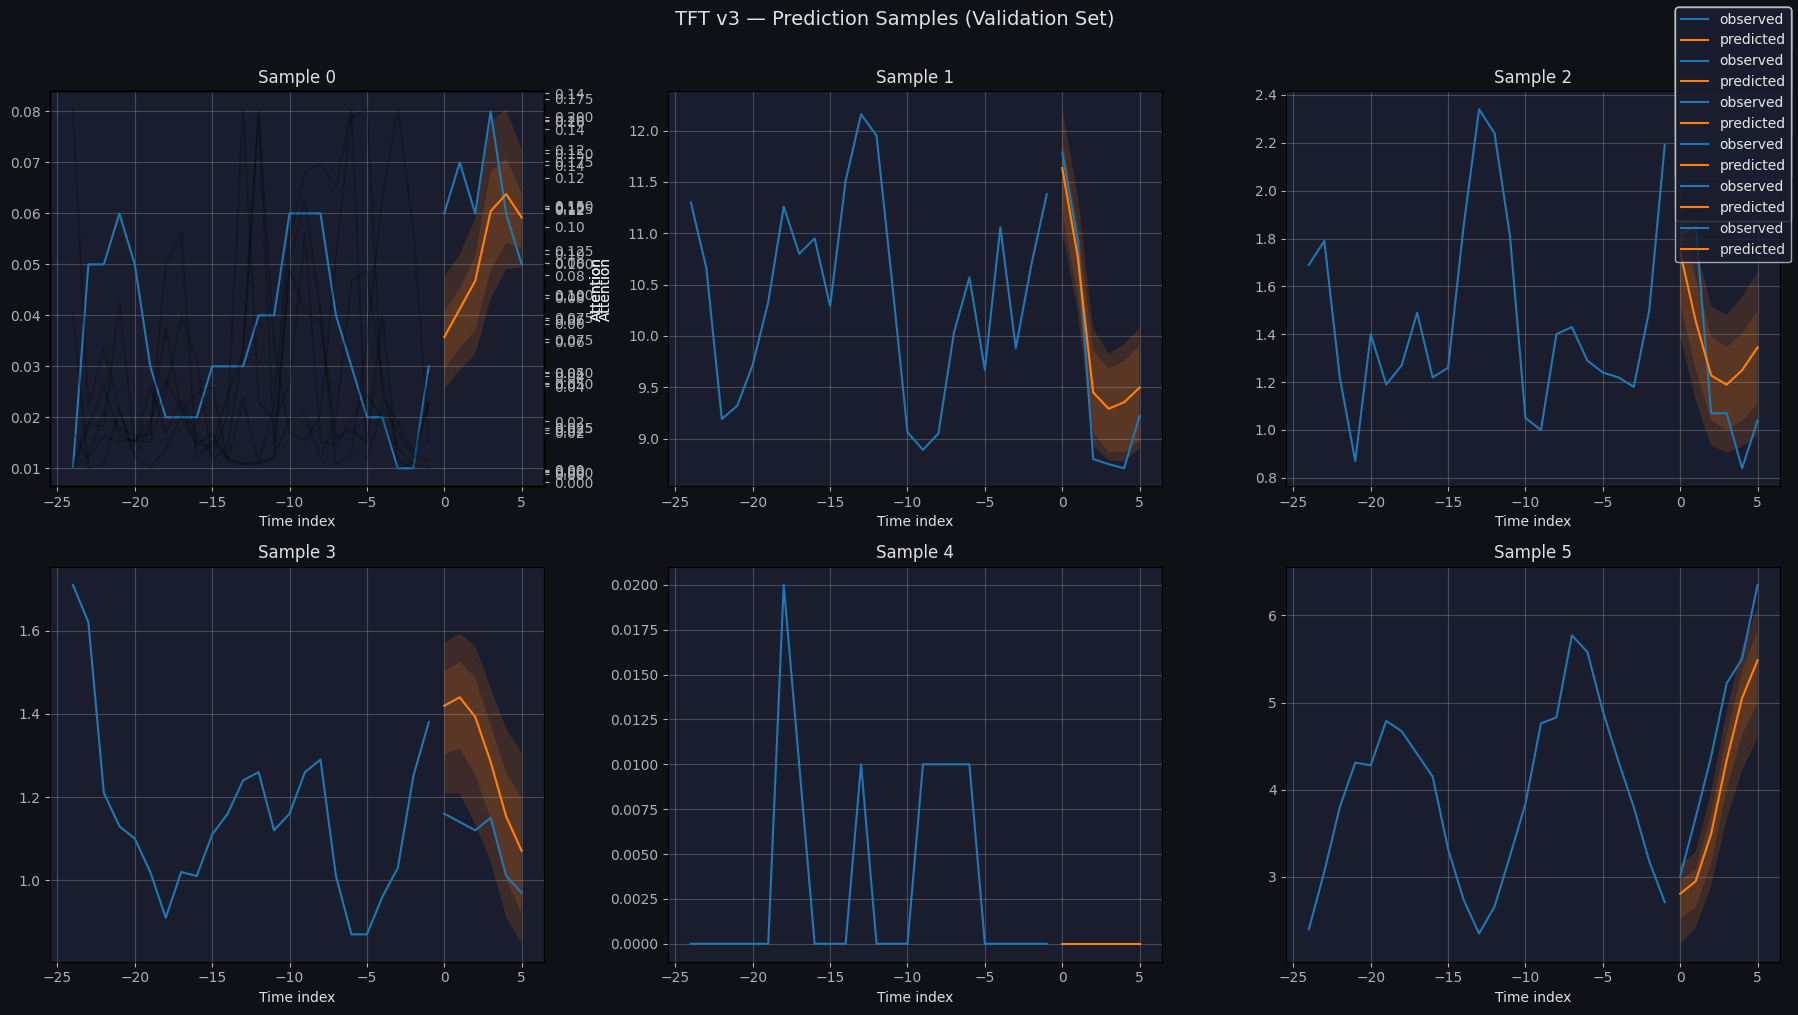

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 13 — VISUALIZE PREDICTIONS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d2e',
    'text.color': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#b0b0b0', 'ytick.color': '#b0b0b0',
})

# Plot 6 prediction samples
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, ax in enumerate(axes.flatten()):
    try:
        best_model.plot_prediction(
            raw_preds.x, raw_preds.output, idx=i, ax=ax,
        )
        ax.set_title(f'Sample {i}')
        ax.grid(alpha=0.3)
    except Exception:
        ax.set_visible(False)

plt.suptitle('TFT v3 — Prediction Samples (Validation Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

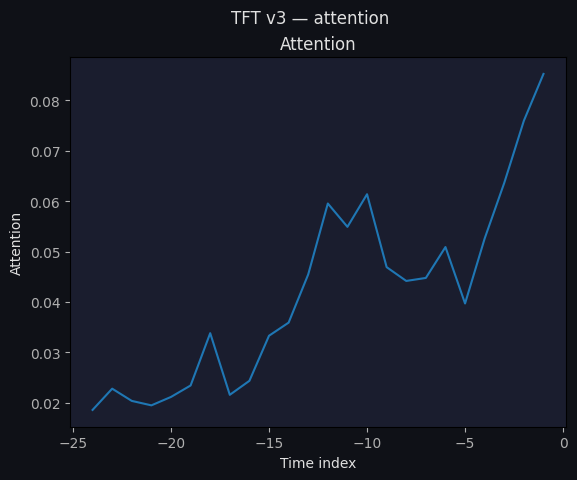

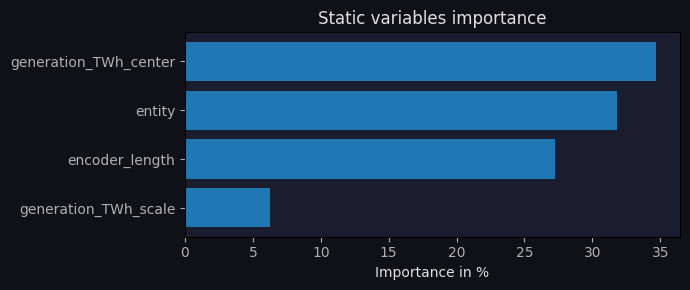

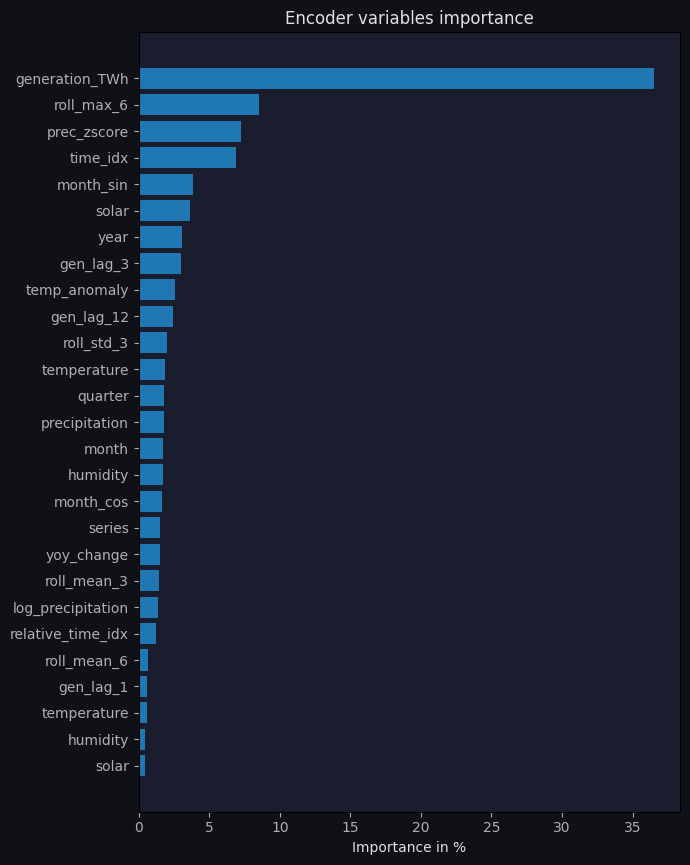

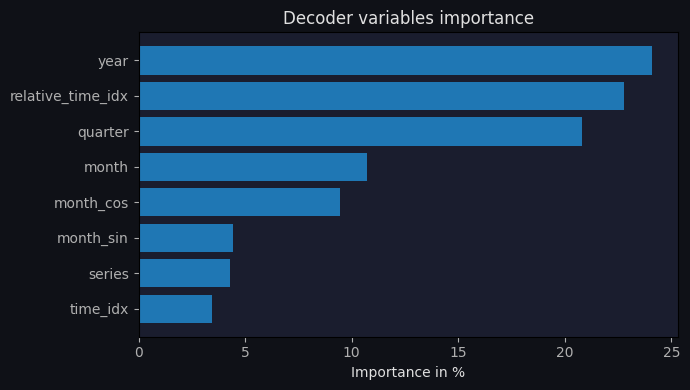

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


📊 Encoder Variable Importance (top 10):
year                     55.172993
roll_mean_6              12.918638
precipitation            10.982468
generation_TWh_center    10.464521
time_idx                  5.796998
humidity                  5.517024
month_cos                 4.633942
prec_zscore               4.515909
roll_max_6                3.844809
gen_lag_1                 3.696075


In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 14 — INTERPRETABILITY: Variable Importance
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
interpretation = best_model.interpret_output(
    raw_preds.output, reduction='sum'
)
figs = best_model.plot_interpretation(interpretation)
for title, fig in figs.items():
    if hasattr(fig, 'suptitle'):      # đảm bảo là Figure thật
        fig.suptitle(f'TFT v3 — {title}', fontsize=12)
        plt.tight_layout()
        plt.show()

# In top features
print('\n📊 Encoder Variable Importance (top 10):')
enc = interpretation.get('encoder_variables')
if enc is not None:
    names = training.reals
    imp   = pd.Series(enc.numpy(), index=names[:len(enc)])
    print(imp.sort_values(ascending=False).head(10).to_string())

In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 15 — TRAINING LOSS CURVE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Đọc log từ TensorBoard
import glob
log_base = str(BASE_DIR / 'lightning_logs')
event_files = glob.glob(log_base + '/**/events.out*', recursive=True)

try:
    from tensorboard.backend.event_file_loader import EventFileLoader
    train_losses, val_losses = [], []
    for ef in event_files:
        loader = EventFileLoader(ef)
        for event in loader.Load():
            for v in event.summary.value:
                if v.tag == 'train_loss_epoch':
                    train_losses.append(v.simple_value)
                if v.tag == 'val_loss':
                    val_losses.append(v.simple_value)

    if train_losses or val_losses:
        fig, ax = plt.subplots(figsize=(13, 5))
        if train_losses:
            ax.plot(train_losses, label='Train Loss', color='#4fc3f7', linewidth=2)
        if val_losses:
            ax.plot(val_losses, label='Val Loss', color='#f06292', linewidth=2)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('QuantileLoss')
        ax.set_title('Training & Validation Loss Curve')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print('Không tìm thấy loss events trong log.')
except ImportError:
    pass

print(f'\n📊 Xem Training Curve đầy đủ trong TensorBoard:')
print(f'   tensorboard --logdir "{log_base}"')


📊 Xem Training Curve đầy đủ trong TensorBoard:
   tensorboard --logdir "C:\Users\ADMIN\Downloads\MODEL_TFT\lightning_logs"


In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 16 — TỔNG KẾT & NEXT STEPS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('╔══════════════════════════════════════════════════════════════╗')
print('║                     KẾT QUẢ TRAINING                        ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Best val_loss : {checkpoint_callback.best_model_score:.6f}                        ║')
print(f'║  Epoch dừng   : {trainer.current_epoch}                                    ║')
print(f'║  MAE          : {mae:.4f} TWh                               ║')
print(f'║  RMSE         : {rmse:.4f} TWh                              ║')
print(f'║  SMAPE        : {smape:.2f}%                                ║')
print(f'║  WAPE         : {wape:.2f}%                                 ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Best checkpoint : tft_v3_best.ckpt                         ║')
print(f'║  Config JSON     : tft_v3_config.json                       ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║  NEXT STEPS — Transfer Learning sang VN:                     ║')
print('║  1. Load: TemporalFusionTransformer                          ║')
print('║           .load_from_checkpoint("tft_v3_best.ckpt")          ║')
print('║  2. Tạo TimeSeriesDataSet từ vn_tft_ready.csv                ║')
print('║  3. Freeze encoder → Fine-tune với LR = 3e-5                 ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║                     KẾT QUẢ TRAINING                        ║
╠══════════════════════════════════════════════════════════════╣
║  Best val_loss : 0.204411                        ║
║  Epoch dừng   : 26                                    ║
║  MAE          : 0.2733 TWh                               ║
║  RMSE         : 0.5171 TWh                              ║
║  SMAPE        : 27.15%                                ║
║  WAPE         : 12.11%                                 ║
╠══════════════════════════════════════════════════════════════╣
║  Best checkpoint : tft_v3_best.ckpt                         ║
║  Config JSON     : tft_v3_config.json                       ║
╠══════════════════════════════════════════════════════════════╣
║  NEXT STEPS — Transfer Learning sang VN:                     ║
║  1. Load: TemporalFusionTransformer                          ║
║           .load_from_checkpoint("tft_v3_best.ckpt")          ║
║  2

In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 17 — [UTILITY] VERIFY CHECKPOINT
# Chạy cell này sau khi restart notebook để kiểm tra checkpoint
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def verify_checkpoint(ckpt_path):
    """Load và in thông tin checkpoint."""
    path = Path(ckpt_path)
    if not path.exists():
        print(f'❌ Không tìm thấy: {ckpt_path}')
        return

    ckpt = torch.load(str(path), map_location='cpu')
    hp   = ckpt.get('hyper_parameters', {})
    cbs  = ckpt.get('callbacks', {})
    val_loss = None
    for k, v in cbs.items():
        if 'ModelCheckpoint' in str(k):
            val_loss = v.get('best_model_score', None)

    size_mb = path.stat().st_size / 1024 / 1024
    print(f'✅ Checkpoint: {path.name} ({size_mb:.1f} MB)')
    print(f'   Epoch        : {ckpt.get("epoch", "N/A")}')
    print(f'   Global step  : {ckpt.get("global_step", "N/A")}')
    print(f'   Best val_loss: {val_loss}')
    print(f'   Hidden size  : {hp.get("hidden_size", "N/A")}')
    print(f'   LR           : {hp.get("learning_rate", "N/A")}')
    return ckpt

# Kiểm tra best checkpoint
BEST_CKPT = Path(r'C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint') / 'tft_v3_best.ckpt'
_ = verify_checkpoint(BEST_CKPT)

✅ Checkpoint: tft_v3_best.ckpt (18.2 MB)
   Epoch        : 13
   Global step  : 2884
   Best val_loss: 0.20441123843193054
   Hidden size  : 128
   LR           : 0.0003


NameError: name 'SERIES_COLORS' is not defined

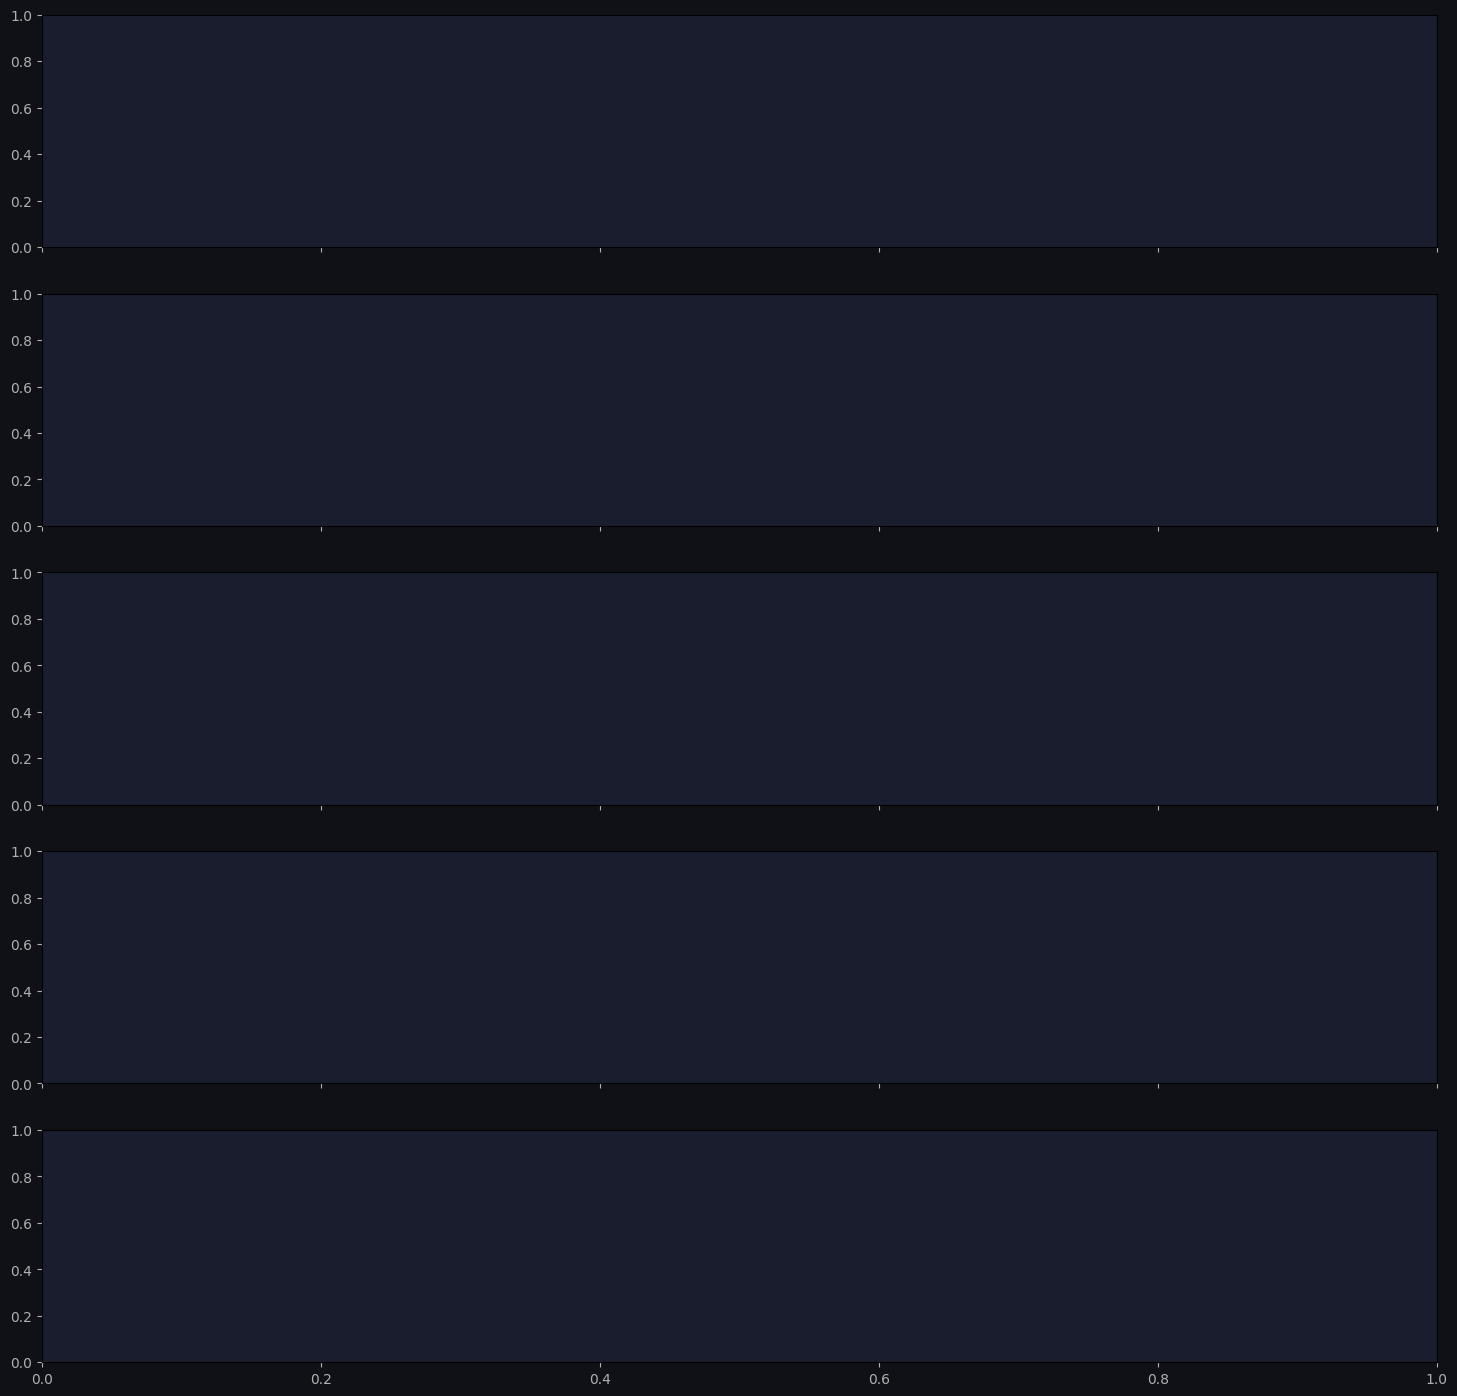

In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 18 — TỔNG QUAN: TRAIN / VAL / TEST SPLIT VISUALIZATION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FINE_TUNE_SERIES = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']  # series muốn hiển thị
# df trong trainTFT_v3 là đa quốc gia → lọc 1 quốc gia để dễ nhìn
# Chọn 1 entity ví dụ 'Australia', hoặc để nguyên nếu muốn xem tất cả
df = df[df['entity'] == 'Australia'].copy()   # ← đổi tên quốc gia tùy ý
TRAIN_END = pd.Timestamp('2023-06-01')
VAL_END   = pd.Timestamp('2024-06-01')
TEST_END  = df['date'].max()

fig, axes = plt.subplots(len(FINE_TUNE_SERIES), 1,
                         figsize=(18, 3.5 * len(FINE_TUNE_SERIES)),
                         sharex=True)

for ax, ser in zip(axes, FINE_TUNE_SERIES):
    sub   = df[df['series'] == ser].sort_values('date')
    color = SERIES_COLORS.get(ser, '#aaa')

    # ── Vùng màu nền ─────────────────────────────────────────────────────────
    ax.axvspan(sub['date'].min(), TRAIN_END,
               alpha=0.12, color='#4fc3f7', label='_nolegend_')
    ax.axvspan(TRAIN_END, VAL_END,
               alpha=0.15, color='#fff176', label='_nolegend_')
    ax.axvspan(VAL_END, TEST_END + pd.DateOffset(days=15),
               alpha=0.18, color='#f06292', label='_nolegend_')

    # ── Đường ranh giới ───────────────────────────────────────────────────────
    ax.axvline(TRAIN_END, color='#4fc3f7', linewidth=1.5, linestyle='--', alpha=0.9)
    ax.axvline(VAL_END,   color='#fff176', linewidth=1.5, linestyle='--', alpha=0.9)

    # ── Dữ liệu thực tế ───────────────────────────────────────────────────────
    # Train
    train_sub = sub[sub['date'] <= TRAIN_END]
    ax.plot(train_sub['date'], train_sub['generation_TWh'],
            color=color, linewidth=2.0, label='Train')
    ax.fill_between(train_sub['date'], train_sub['generation_TWh'],
                    alpha=0.2, color=color)

    # Val
    val_sub = sub[(sub['date'] > TRAIN_END) & (sub['date'] <= VAL_END)]
    ax.plot(val_sub['date'], val_sub['generation_TWh'],
            color=color, linewidth=2.0, linestyle='--')

    # Test
    test_sub = sub[sub['date'] > VAL_END]
    ax.plot(test_sub['date'], test_sub['generation_TWh'],
            color=color, linewidth=2.5, linestyle='-',
            marker='o', markersize=5)

    # ── Rolling mean overlay ──────────────────────────────────────────────────
    roll = sub.set_index('date')['generation_TWh'].rolling(3, center=True).mean()
    ax.plot(roll.index, roll.values,
            color='white', linewidth=1.2, alpha=0.55,
            linestyle=':', label='Roll Mean 3m')

    # ── Labels chú thích vùng ─────────────────────────────────────────────────
    y_top = sub['generation_TWh'].max() * 1.05
    ax.text(pd.Timestamp('2019-06-01'), y_top * 0.93,
            'TRAIN', color='#4fc3f7', fontsize=10, fontweight='bold', alpha=0.9)
    ax.text(pd.Timestamp('2023-08-01'), y_top * 0.93,
            'VAL', color='#fff176', fontsize=10, fontweight='bold', alpha=0.9)
    ax.text(pd.Timestamp('2024-07-15'), y_top * 0.93,
            'TEST', color='#f06292', fontsize=10, fontweight='bold', alpha=0.9)

    # ── Trục & lưới ──────────────────────────────────────────────────────────
    ax.set_ylabel('TWh', fontsize=10)
    ax.set_title(f'{ser}', fontsize=12, pad=6)
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Legend chung ─────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color='#4fc3f7', alpha=0.5, label='Train (2019-01 → 2023-06)'),
    mpatches.Patch(color='#fff176', alpha=0.6, label='Val   (2023-07 → 2024-06)'),
    mpatches.Patch(color='#f06292', alpha=0.6, label='Test  (2024-07 → 2024-12)'),
    plt.Line2D([0], [0], color='white', linewidth=1.5,
               linestyle=':', label='Rolling Mean 3m'),
]
fig.legend(handles=legend_patches, loc='upper center', ncol=4,
           fontsize=10, framealpha=0.3,
           bbox_to_anchor=(0.5, 1.01))

fig.suptitle(
    'VN Transfer Learning — Phân chia Train / Validation / Test\n'
    'Moi series: 72 thang (2019-2024)',
    fontsize=14, y=1.04
)
plt.tight_layout()
plt.show()

# ── Bảng tóm tắt số liệu mỗi split ──────────────────────────────────────────
print('\nBang tom tat so lieu moi split:')
print(f'{"Split":<8} {"Tu":<12} {"Den":<12} {"Thang":>6}')
print('-' * 42)
splits = [
    ('Train', df["date"].min(), TRAIN_END),
    ('Val',   TRAIN_END + pd.DateOffset(months=1), VAL_END),
    ('Test',  VAL_END + pd.DateOffset(months=1),   TEST_END),
]
for name, start, end in splits:
    n = len(pd.date_range(start, end, freq='MS'))
    print(f'{name:<8} {str(start.date()):<12} {str(end.date()):<12} {n:>6}')
